# Evaluation Analysis

Interactive analysis notebook for spoofing detection evaluation results.

**Section 1** explores raw simulation CSVs: spoofing distances and distance discrepancies.

**Section 2** analyzes pre-computed score CSVs from `unified_eval.py score`: ROC curves, confusion matrices, and threshold exploration.

In [47]:
import sys
sys.path.insert(0, '../..')
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(precision=4, suppress=True)
import pandas as pd

---
## Section 1: Raw Simulation CSV Exploration

Load raw simulation CSVs and compute spoofing distance and distance discrepancy statistics.

In [48]:
# Configuration
DATA_DIR = '../../datasets/current/test'

# Set to None to process all CSVs
LIMIT = 50

In [49]:
from pathlib import Path
from evaluations.data import load_scenario
from evaluations.scoring import compute_sample_distances
from evaluations.metrics import compute_distance_stats

csv_files = sorted(Path(DATA_DIR).glob('*.csv'))
if LIMIT:
    csv_files = csv_files[:LIMIT]
print(f'Loading {len(csv_files)} scenarios from {DATA_DIR}...')

all_spoofing_dists = []
all_dist_discrepancies = []

for csv_path in csv_files:
    scenario = load_scenario(csv_path)
    spoofing_dist, dist_discrepancy = compute_sample_distances(scenario)
    
    # Only keep spoofed events
    spoofed_mask = scenario.is_spoofed.astype(bool)
    if spoofed_mask.any():
        all_spoofing_dists.append(spoofing_dist[spoofed_mask])
        all_dist_discrepancies.append(dist_discrepancy[spoofed_mask])

all_spoofing_dists = np.concatenate(all_spoofing_dists) if all_spoofing_dists else np.array([])
all_dist_discrepancies = np.concatenate(all_dist_discrepancies) if all_dist_discrepancies else np.array([])

print(f'Spoofed RX events: {len(all_spoofing_dists)}')

Loading 50 scenarios from ../../datasets/current/test...
Spoofed RX events: 141699


In [50]:
# Spoofing distance stats
stats = compute_distance_stats(all_spoofing_dists)
print('Spoofing Distance: ||tx_actual - rid_claimed||')
print(f"  Count:   {stats['count']}")
if stats['mean'] is not None:
    print(f"  Mean:    {stats['mean']:.2f} m")
    print(f"  Std:     {stats['std']:.2f} m")
    print(f"  Min:     {stats['min']:.2f} m")
    print(f"  Max:     {stats['max']:.2f} m")
    print(f"  Median:  {stats['median']:.2f} m")
    print(f"  P25:     {stats['p25']:.2f} m")
    print(f"  P75:     {stats['p75']:.2f} m")
    print(f"  P90:     {stats['p90']:.2f} m")
    print(f"  P95:     {stats['p95']:.2f} m")

print()
stats = compute_distance_stats(all_dist_discrepancies)
print('Distance Discrepancy: ||tx_actual - rx|| - ||rid_claimed - rx||')
print(f"  Count:   {stats['count']}")
if stats['mean'] is not None:
    print(f"  Mean:    {stats['mean']:.2f} m")
    print(f"  Std:     {stats['std']:.2f} m")
    print(f"  Min:     {stats['min']:.2f} m")
    print(f"  Max:     {stats['max']:.2f} m")
    print(f"  Median:  {stats['median']:.2f} m")

Spoofing Distance: ||tx_actual - rid_claimed||
  Count:   141699
  Mean:    288.87 m
  Std:     147.40 m
  Min:     2.23 m
  Max:     825.75 m
  Median:  273.52 m
  P25:     174.75 m
  P75:     387.02 m
  P90:     482.09 m
  P95:     555.39 m

Distance Discrepancy: ||tx_actual - rx|| - ||rid_claimed - rx||
  Count:   141699
  Mean:    -15.37 m
  Std:     185.64 m
  Min:     -748.00 m
  Max:     711.52 m
  Median:  -11.98 m


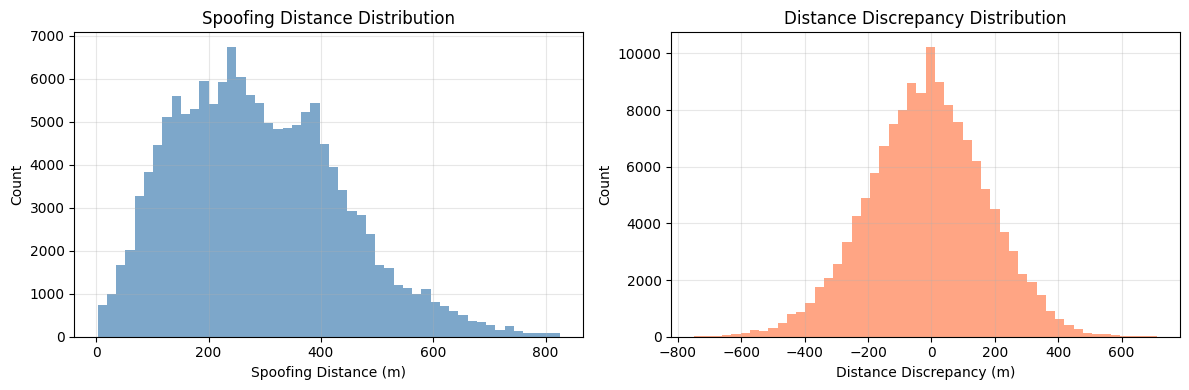

In [51]:
# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(all_spoofing_dists, bins=50, alpha=0.7, color='steelblue')
ax.set_xlabel('Spoofing Distance (m)')
ax.set_ylabel('Count')
ax.set_title('Spoofing Distance Distribution')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(all_dist_discrepancies, bins=50, alpha=0.7, color='coral')
ax.set_xlabel('Distance Discrepancy (m)')
ax.set_ylabel('Count')
ax.set_title('Distance Discrepancy Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 2: Score CSV Analysis

Analyze pre-computed score CSVs from `unified_eval.py score`.

**Prerequisites:** Run the score stage first to generate the required files:
```bash
.venv/bin/python -m evaluations.unified_eval score \
    --test-dir datasets/scitech26-1920-scenarios/test \
    --kf-threshold 0.6254 --mlat-threshold 114.3571 \
    --test-limit 50 -o evaluations/results
```

In [52]:
# Configuration — point to the directory where you ran the 'score' subcommand
SCORES_DIR = '../../evaluations/results/current'

# Verify files exist
from pathlib import Path
scores_path = Path(SCORES_DIR)
for f in ['kf_scores.csv', 'mlat_scores.csv', 'thresholds.json', 'mlp_scores.csv']:
    exists = (scores_path / f).exists()
    print(f"  {f}: {'OK' if exists else 'MISSING'}")
if not (scores_path / 'kf_scores.csv').exists():
    print("\nRun the 'score' stage first (see instructions above).")

  kf_scores.csv: OK
  mlat_scores.csv: OK
  thresholds.json: OK
  mlp_scores.csv: OK


In [53]:
import json

kf_df = pd.read_csv(scores_path / 'kf_scores.csv')
mlat_df = pd.read_csv(scores_path / 'mlat_scores.csv')

thresholds_path = scores_path / 'thresholds.json'
if thresholds_path.exists():
    with open(thresholds_path) as f:
        thresholds = json.load(f)
    kf_threshold = thresholds['kf_threshold']
    mlat_threshold = thresholds['mlat_threshold']
    print(f'KF threshold:   {kf_threshold}')
    print(f'MLAT threshold: {mlat_threshold}')
else:
    print('No thresholds.json found - set thresholds manually below')
    kf_threshold = 0.6254
    mlat_threshold = 114.3571

print(f'\nKF scores:   {len(kf_df)} events ({kf_df["is_spoofed"].sum()} spoofed)')
print(f'MLAT scores: {len(mlat_df)} events ({mlat_df["is_spoofed"].sum()} spoofed)')

# Load MLP scores if available
mlp_df = None
mlp_threshold = 0.5
mlp_path = scores_path / 'mlp_scores.csv'
if mlp_path.exists():
    mlp_df = pd.read_csv(mlp_path)
    # Drop rows without MLP scores (scenarios not covered by MLP)
    mlp_df = mlp_df.dropna(subset=['mlp_score'])
    print(f'MLP scores:  {len(mlp_df)} events ({mlp_df["is_spoofed"].sum()} spoofed)')
else:
    print('MLP scores:  not available (no mlp_scores.csv)')

KF threshold:   0.72100830291403
MLAT threshold: 147.12817658856574

KF scores:   11219942 events (1636121 spoofed)
MLAT scores: 1291812 events (335782 spoofed)
MLP scores:  647050 events (174106 spoofed)


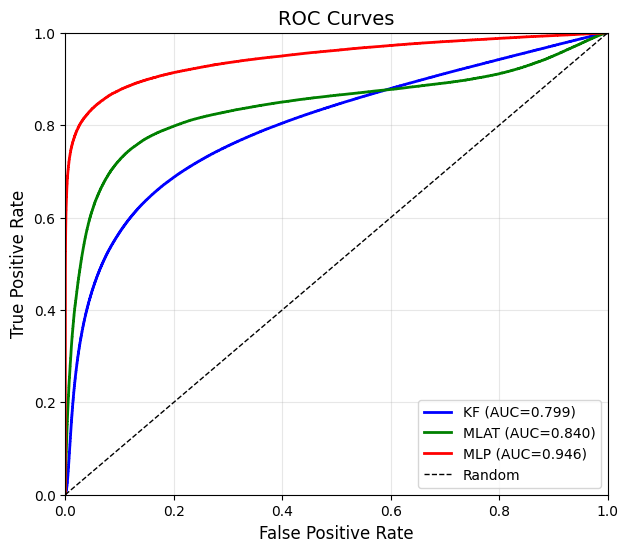

KF AUC:   0.7986
MLAT AUC: 0.8399
MLP AUC:  0.9455


In [54]:
# ROC Curves
from evaluations.metrics import compute_roc_auc

kf_auc, kf_fpr, kf_tpr, _ = compute_roc_auc(
    kf_df['is_spoofed'].values, kf_df['kf_score'].values)
mlat_auc, mlat_fpr, mlat_tpr, _ = compute_roc_auc(
    mlat_df['is_spoofed'].values, mlat_df['mlat_score'].values)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(kf_fpr, kf_tpr, 'b-', linewidth=2, label=f'KF (AUC={kf_auc:.3f})')
ax.plot(mlat_fpr, mlat_tpr, 'g-', linewidth=2, label=f'MLAT (AUC={mlat_auc:.3f})')

if mlp_df is not None:
    mlp_auc, mlp_fpr, mlp_tpr, _ = compute_roc_auc(
        mlp_df['is_spoofed'].values, mlp_df['mlp_score'].values)
    ax.plot(mlp_fpr, mlp_tpr, 'r-', linewidth=2, label=f'MLP (AUC={mlp_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.show()

print(f'KF AUC:   {kf_auc:.4f}')
print(f'MLAT AUC: {mlat_auc:.4f}')
if mlp_df is not None:
    print(f'MLP AUC:  {mlp_auc:.4f}')

In [55]:
# Confusion matrix at threshold
def print_confusion(name, scores, labels, threshold):
    preds = scores >= threshold
    tp = ((preds) & (labels)).sum()
    tn = ((~preds) & (~labels)).sum()
    fp = ((preds) & (~labels)).sum()
    fn = ((~preds) & (labels)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{name} (threshold={threshold}):')
    print(f'  TP={tp}, TN={tn}, FP={fp}, FN={fn}')
    print(f'  TPR={tpr:.4f}, FPR={fpr:.4f}')
    return tp, tn, fp, fn

kf_labels = kf_df['is_spoofed'].values.astype(bool)
mlat_labels = mlat_df['is_spoofed'].values.astype(bool)

print_confusion('KF', kf_df['kf_score'].values, kf_labels, kf_threshold)
print()
print_confusion('MLAT', mlat_df['mlat_score'].values, mlat_labels, mlat_threshold)

if mlp_df is not None:
    mlp_labels = mlp_df['is_spoofed'].values.astype(bool)
    print()
    print_confusion('MLP', mlp_df['mlp_score'].values, mlp_labels, mlp_threshold)

KF (threshold=0.72100830291403):
  TP=1078588, TN=7959621, FP=1624200, FN=557533
  TPR=0.6592, FPR=0.1695

MLAT (threshold=147.12817658856574):
  TP=264519, TN=785484, FP=170546, FN=71263
  TPR=0.7878, FPR=0.1784

MLP (threshold=0.5):
  TP=146457, TN=446928, FP=26016, FN=27649
  TPR=0.8412, FPR=0.0550


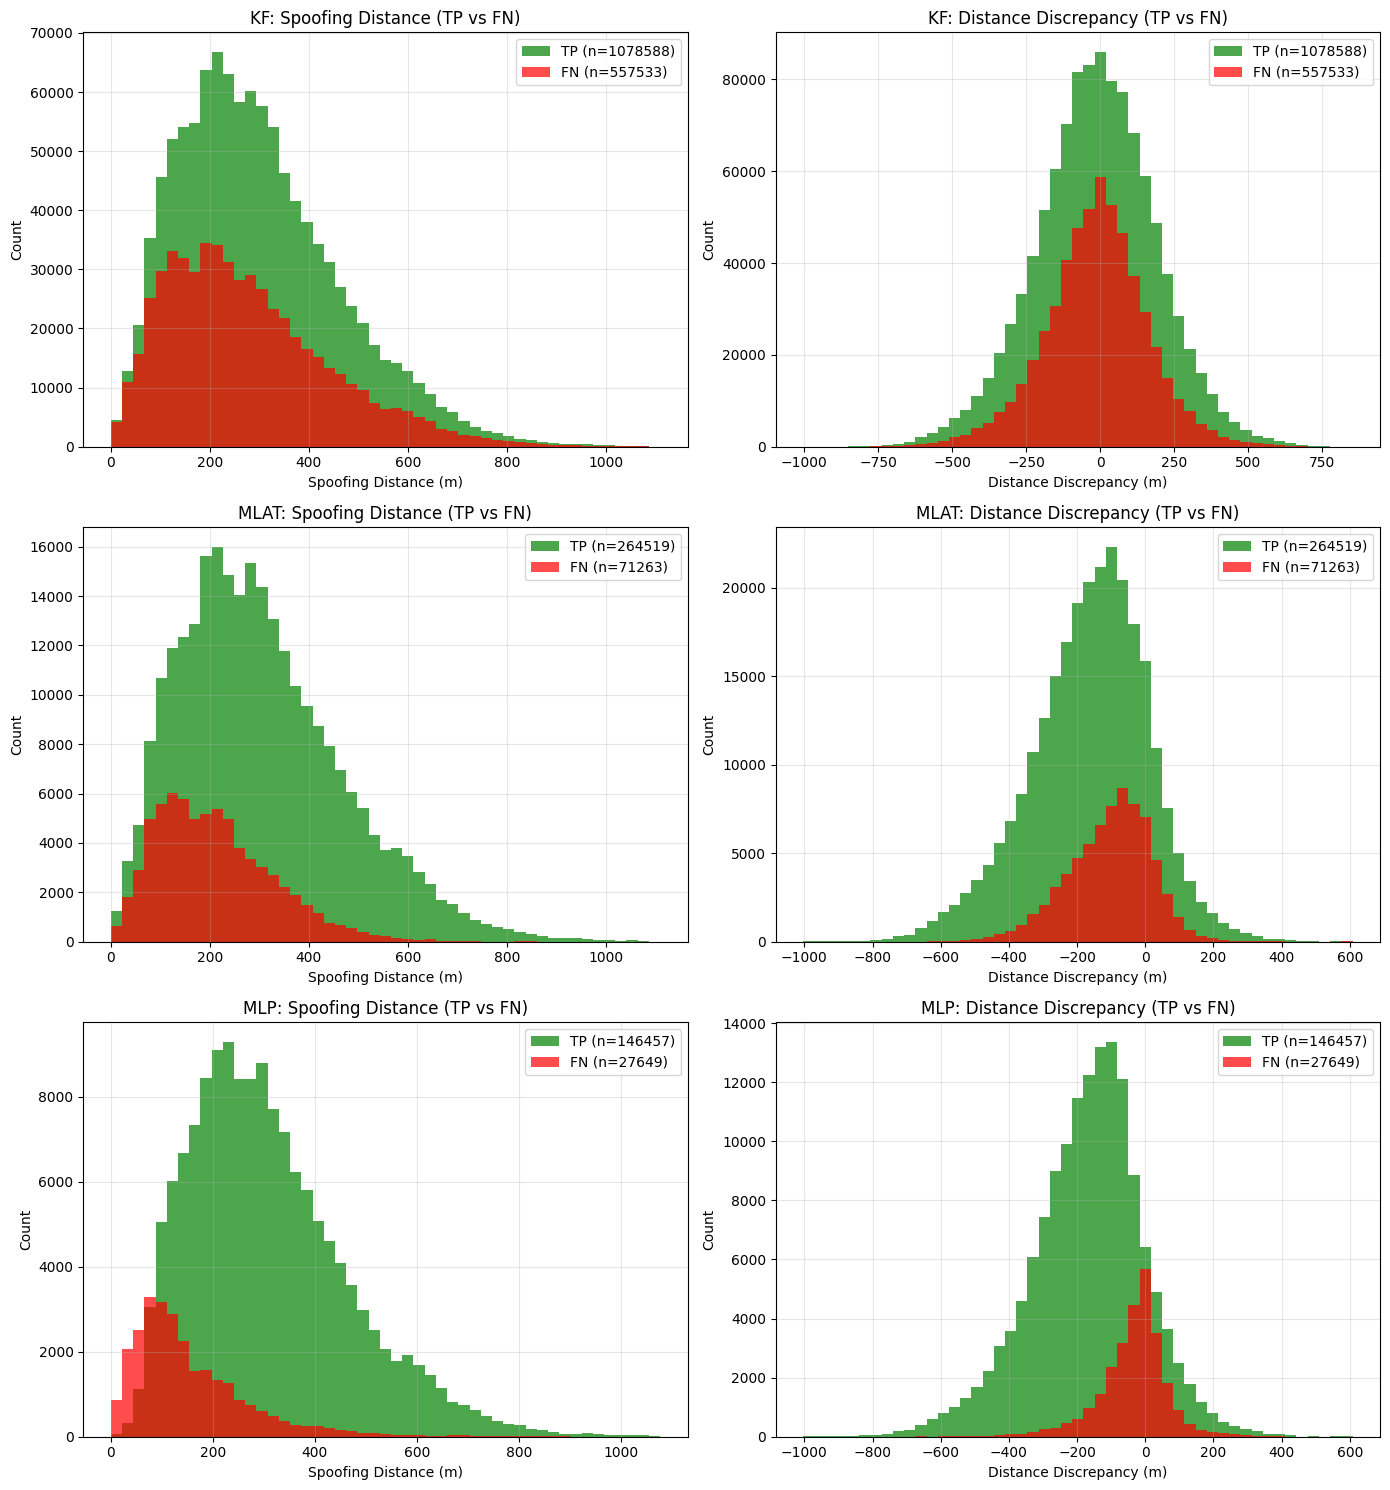

In [56]:
# TP vs FN distance breakdown histograms
def dropnan(arr):
    return arr[~np.isnan(arr)]

methods = [
    ('KF', kf_df, 'kf_score', kf_threshold),
    ('MLAT', mlat_df, 'mlat_score', mlat_threshold),
]
if mlp_df is not None:
    methods.append(('MLP', mlp_df, 'mlp_score', mlp_threshold))

n_rows = len(methods)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, (name, df, score_col, threshold) in enumerate(methods):
    labels = df['is_spoofed'].values.astype(bool)
    preds = df[score_col].values >= threshold
    spoofed = labels
    tp_mask = spoofed & preds
    fn_mask = spoofed & ~preds

    spoof_dists = df['spoofing_dist'].values
    disc = df['distance_discrepancy'].values

    # Spoofing distance
    ax = axes[row, 0]
    valid = dropnan(spoof_dists[spoofed])
    bins = np.linspace(0, max(np.nanmax(valid), 1), 50) if len(valid) else 50
    ax.hist(dropnan(spoof_dists[tp_mask]), bins=bins, alpha=0.7,
            label=f'TP (n={tp_mask.sum()})', color='green')
    ax.hist(dropnan(spoof_dists[fn_mask]), bins=bins, alpha=0.7,
            label=f'FN (n={fn_mask.sum()})', color='red')
    ax.set_xlabel('Spoofing Distance (m)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}: Spoofing Distance (TP vs FN)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Distance discrepancy
    ax = axes[row, 1]
    valid = dropnan(disc[spoofed])
    bins = np.linspace(valid.min(), valid.max(), 50) if len(valid) else 50
    ax.hist(dropnan(disc[tp_mask]), bins=bins, alpha=0.7,
            label=f'TP (n={tp_mask.sum()})', color='green')
    ax.hist(dropnan(disc[fn_mask]), bins=bins, alpha=0.7,
            label=f'FN (n={fn_mask.sum()})', color='red')
    ax.set_xlabel('Distance Discrepancy (m)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}: Distance Discrepancy (TP vs FN)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
# Threshold exploration: vary threshold, see TPR/FPR change
print('KF Threshold Exploration:')
print(f'{"Threshold":>12} {"TPR":>8} {"FPR":>8} {"TP":>8} {"FP":>8} {"FN":>8}')
print('-' * 60)
kf_scores = kf_df['kf_score'].values
for t in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 3.84, 5.0, 10.0]:
    preds = kf_scores >= t
    tp = ((preds) & (kf_labels)).sum()
    fp = ((preds) & (~kf_labels)).sum()
    fn = ((~preds) & (kf_labels)).sum()
    tn = ((~preds) & (~kf_labels)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{t:>12.4f} {tpr:>8.4f} {fpr:>8.4f} {tp:>8} {fp:>8} {fn:>8}')

print()
print('MLAT Threshold Exploration:')
print(f'{"Threshold":>12} {"TPR":>8} {"FPR":>8} {"TP":>8} {"FP":>8} {"FN":>8}')
print('-' * 60)
mlat_scores = mlat_df['mlat_score'].values
for t in [10, 25, 50, 75, 100, 114, 150, 200, 300, 500]:
    preds = mlat_scores >= t
    tp = ((preds) & (mlat_labels)).sum()
    fp = ((preds) & (~mlat_labels)).sum()
    fn = ((~preds) & (mlat_labels)).sum()
    tn = ((~preds) & (~mlat_labels)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{t:>12.4f} {tpr:>8.4f} {fpr:>8.4f} {tp:>8} {fp:>8} {fn:>8}')

if mlp_df is not None:
    mlp_scores = mlp_df['mlp_score'].values
    print()
    print('MLP Threshold Exploration:')
    print(f'{"Threshold":>12} {"TPR":>8} {"FPR":>8} {"TP":>8} {"FP":>8} {"FN":>8}')
    print('-' * 60)
    for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        preds = mlp_scores >= t
        tp = ((preds) & (mlp_labels)).sum()
        fp = ((preds) & (~mlp_labels)).sum()
        fn = ((~preds) & (mlp_labels)).sum()
        tn = ((~preds) & (~mlp_labels)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f'{t:>12.4f} {tpr:>8.4f} {fpr:>8.4f} {tp:>8} {fp:>8} {fn:>8}')

KF Threshold Exploration:
   Threshold      TPR      FPR       TP       FP       FN
------------------------------------------------------------
      0.1000   0.8639   0.5548  1413448  5317447   222673
      0.2000   0.8110   0.4155  1326862  3981822   309259
      0.4000   0.7389   0.2724  1208920  2610435   427201
      0.6000   0.6860   0.1987  1122334  1904594   513787
      0.8000   0.6432   0.1542  1052373  1478248   583748
      1.0000   0.6066   0.1247   992487  1194901   643634
      2.0000   0.4775   0.0603   781195   577549   854926
      3.8400   0.3397   0.0288   555795   276108  1080326
      5.0000   0.2828   0.0214   462750   205374  1173371
     10.0000   0.1497   0.0109   244925   104358  1391196

MLAT Threshold Exploration:
   Threshold      TPR      FPR       TP       FP       FN
------------------------------------------------------------
     10.0000   0.9753   0.9478   327473   906133     8309
     25.0000   0.9495   0.8989   318822   859341    16960
     50.000

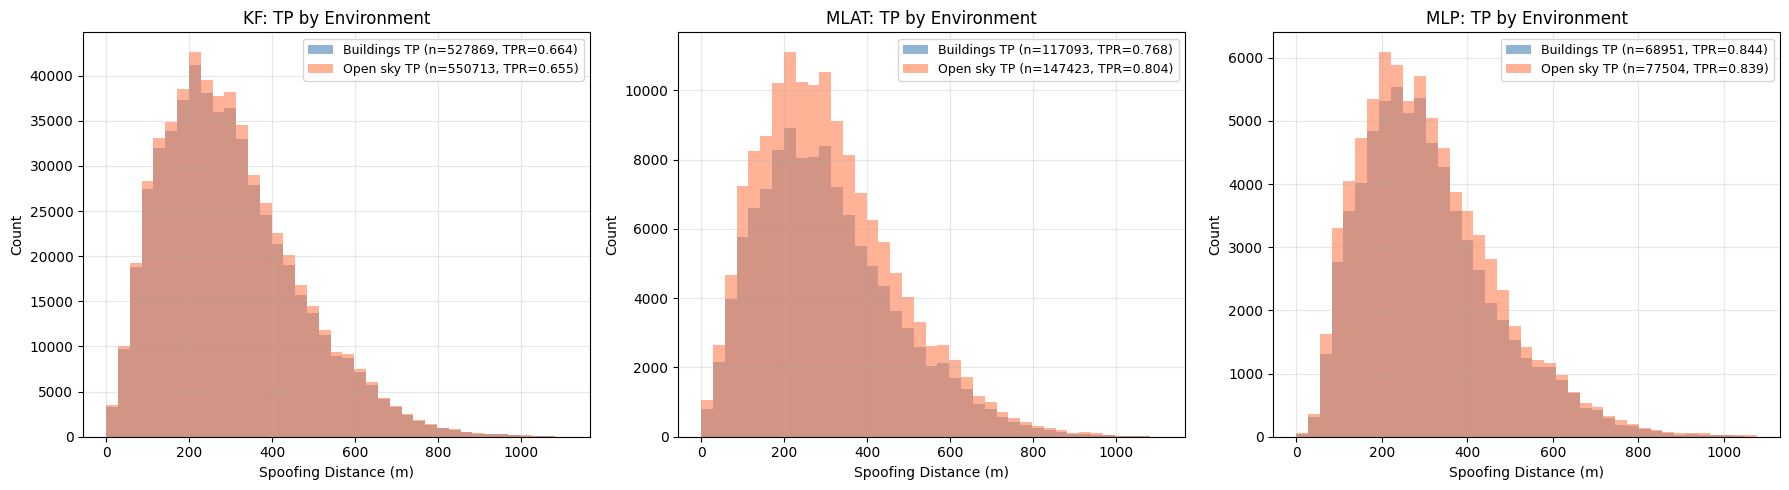

Method   Env           Spoofed       TP       FN      TPR      FPR
--------------------------------------------------------------------
KF       buildings      795560   527872   267688   0.6635   0.1750
KF       open sky       840561   550716   289845   0.6552   0.1643
MLAT     buildings      152410   117094    35316   0.7683   0.1638
MLAT     open sky       183372   147425    35947   0.8040   0.1906
MLP      buildings       81735    68951    12784   0.8436   0.0578
MLP      open sky        92371    77506    14865   0.8391   0.0524


In [58]:
# TP rate comparison: buildings (-b) vs open sky (-o) across all detectors
methods = [
    ('KF', kf_df, 'kf_score', kf_threshold),
    ('MLAT', mlat_df, 'mlat_score', mlat_threshold),
]
if mlp_df is not None:
    methods.append(('MLP', mlp_df, 'mlp_score', mlp_threshold))

n_methods = len(methods)
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5))
if n_methods == 1:
    axes = [axes]

for ax, (name, df, score_col, threshold) in zip(axes, methods):
    labels = df['is_spoofed'].values.astype(bool)
    scores = df[score_col].values
    preds = scores >= threshold
    tp_mask = labels & preds
    fn_mask = labels & ~preds

    # Split by scenario suffix: -b (buildings) vs -o (open sky)
    has_buildings = df['scenario_id'].str.endswith('-b').values
    open_sky = ~has_buildings

    spoof_dists = df['spoofing_dist'].values

    bldg_tp = dropnan(spoof_dists[tp_mask & has_buildings])
    bldg_fn = dropnan(spoof_dists[fn_mask & has_buildings])
    open_tp = dropnan(spoof_dists[tp_mask & open_sky])
    open_fn = dropnan(spoof_dists[fn_mask & open_sky])

    # Compute TPR per environment
    n_spoof_bldg = (labels & has_buildings).sum()
    n_spoof_open = (labels & open_sky).sum()
    tpr_bldg = (tp_mask & has_buildings).sum() / n_spoof_bldg if n_spoof_bldg > 0 else 0
    tpr_open = (tp_mask & open_sky).sum() / n_spoof_open if n_spoof_open > 0 else 0

    # Histogram of TP spoofing distances, buildings vs open
    all_valid = dropnan(spoof_dists[labels])
    bins = np.linspace(0, max(np.nanmax(all_valid), 1), 40) if len(all_valid) else 40

    ax.hist(bldg_tp, bins=bins, alpha=0.6, label=f'Buildings TP (n={len(bldg_tp)}, TPR={tpr_bldg:.3f})', color='steelblue')
    ax.hist(open_tp, bins=bins, alpha=0.6, label=f'Open sky TP (n={len(open_tp)}, TPR={tpr_open:.3f})', color='coral')
    ax.set_xlabel('Spoofing Distance (m)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}: TP by Environment')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Method":<8} {"Env":<12} {"Spoofed":>8} {"TP":>8} {"FN":>8} {"TPR":>8} {"FPR":>8}')
print('-' * 68)
for name, df, score_col, threshold in methods:
    labels = df['is_spoofed'].values.astype(bool)
    preds = df[score_col].values >= threshold
    has_buildings = df['scenario_id'].str.endswith('-b').values
    for env_name, env_mask in [('buildings', has_buildings), ('open sky', ~has_buildings)]:
        env_labels = labels[env_mask]
        env_preds = preds[env_mask]
        tp = (env_labels & env_preds).sum()
        fn = (env_labels & ~env_preds).sum()
        fp = (~env_labels & env_preds).sum()
        tn = (~env_labels & ~env_preds).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f'{name:<8} {env_name:<12} {(tp+fn):>8} {tp:>8} {fn:>8} {tpr:>8.4f} {fpr:>8.4f}')